![My Logo](./LandingAI_Logo.png)

---

# LandingAI Agentic Document Extraction (ADE) Example
## Background
This notebook demonstrates how to analyze an example - AI-generated - Know Your Customer (KYC) document using LandingAI’s Agentic Document Extraction tool. It showcases both REST API and Python SDK methods, along with visualization tools provided by LandingAI. The notebook also includes an integration with OpenAI for field extraction and question answering, as well as an evaluation pipeline powered by LangChain.

## End-to-End Steps:
1. Package Installs
2. Imports, Example Document Visualization, and Models Instantiation
    - Make sure to adjust the config.py file in this folder and add your API keys for LandingAI ADE & VisionAgents, and OpenAI
3. Document Extraction Methods: LandingAI ADE REST API and LandingAI ADE Python SDK
    - LandingAI ADE REST API Method + Processing Time
    - LandingAI ADE Python SDK Method + Processing Time
    - Visualization Methods
        - Grounding Overlay
        - Markdown
        - Chunks
    - Field Extraction using OpenAI
        - Example of Extracting the Compliance Contact and Their Email Address
        - Example of Requirement Verification: Forms Required
4. Evaluation Pipeline using LangChain and OpenAI
    - Convert the LandingAI Chunks to LangChain Documents
    - Instantiate the OpenAI Embedding Model, Store the Embeddings in a Vectorstore and Create a Retriever
    - Create a QA Chain and Instantiate an OpenAI model for Evaluation
    - Create an Evaluation Dataset
    - Run Predictions
    - Evaluate the Answers using FAISS (Facebook AI Similarity Search)
    - Show the Results
    - Repeat with AI-Generated Questions - Using LLMs for Evaluation

### Make sure to update the config.py file with your own API Keys!
---

# 1. Package Installs

In [ ]:
pip install agentic-doc

In [ ]:
pip install openai

In [ ]:
pip install langchain langchain-community langchain-openai faiss-cpu

---

# 2. Imports, Example Document Visualization, and Models Instantiation

In [1]:
# Standard Imports
import requests
import os
import re
import time
import openai
import json
import matplotlib.pyplot as plt

from config import API_KEYS
from dotenv import load_dotenv
from pprint import pprint
from IPython.display import Markdown, display, IFrame
from PIL import Image

# LandingAI ADE Python SDK 
from agentic_doc.parse import parse_documents
from agentic_doc.utils import viz_parsed_document
from agentic_doc.config import VisualizationConfig

# Langchain for the evaluation pipeline
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.chains import RetrievalQA
from langchain.evaluation.qa import QAEvalChain

# API Keys Import from the config.py file
ADE_API_KEY = API_KEYS["ade"] # LandingAI's Agentic Document extraction API key 
VISION_AGENT_API_KEY = API_KEYS["va"] # LandingAI's VisionAgent API key
OPENAI_API_KEY = API_KEYS["openai"] # OpenAI API Key

# Rest API Endpoint for ADE
url = "https://api.va.landing.ai/v1/tools/agentic-document-analysis"

# Instantiate the client object from OpenAI
client = openai.OpenAI(api_key=OPENAI_API_KEY)

# Loading the document example
kyc_doc = './KYC_EXAMPLE_DOC.pdf'

2025-04-11 15:55:54 [info   ] Settings loaded: {
  "vision_agent_api_key": "dzhra[REDACTED]",
  "batch_size": 4,
  "max_workers": 5,
  "max_retries": 100,
  "max_retry_wait_time": 60,
  "retry_logging_style": "log_msg",
  "pdf_to_image_dpi": 96
} [agentic_doc.config] (config.py:80)


In [2]:
# Visualize the sample Know Your Customer (KCYC) document (PDF)
IFrame(kyc_doc, width=800, height=1200)

---

# 3. Document Extraction Methods

## LandingAI ADE Rest API Method + Processing Time

In [3]:
start_time = time.time()
files = {
  # "image": open("{{file_1}}", "rb")
  # OR, for PDF
  "pdf": open(kyc_doc, "rb")
}
headers = {
  "Authorization": f"Basic {ADE_API_KEY}",
}
response = requests.post(url, files=files, headers=headers)
end_time = time.time()

print(response.json())
print('-----------------------------------------')
print(f"Doc processing took {end_time - start_time:.4f} seconds using LandingAI's ADE Rest API.")

{'data': {'markdown': '# KYC DOCUMENT - INSTITUTIONAL CLIENT <!-- title, from page 0 (l=0.258,t=0.042,r=0.741,b=0.056), with ID 07992dc5-4801-4f7a-a6d6-d812d0946927 -->\n\n## Client Information\n\n- **Client Name**: Acme Global Holdings Ltd.\n- **Registration Number**: 123456789\n- **Incorporation Date**: January 15, 2012\n- **Country of Incorporation**: United Kingdom\n- **Legal Entity Identifier**: 5493001KJTII8C8Y1R12\n- **Tax Identification No.**: GB123456789\n- **Registered Address**: \n  - 123 Finance Street\n  - London, EC1A 1AA\n  - United Kingdom\n- **Operating Address**: \n  - 456 Business Avenue\n  - Canary Wharf, London, E14 5AB\n  - United Kingdom\n\n## Business Details\n\n- **Nature of Business**: Investment Holdings\n- **Industry Sector**: Financial Services\n\n## Contacts\n\n- **Authorized Signatory**: Jane Doe\n  - **Position**: Chief Financial Officer\n  - **Email**: jane.doe@acmeglobal.com\n  - **Phone**: +44 20 7946 1234\n\n- **Compliance Contact**: John Smith\n  - 

## LandingAI ADE Python SDK Method + Processing Time

The Visual Grounding images will be saved to the path specifed for the "grounding_save_dir" parameter where the output path: grounding_save_dir/document_TIMESTAMP/page_X/CHUNK_ID_Y.png
- X is the page number, CHUNK_ID is the unique ID of each chunk
- Y is the index of the grounding within the chunk

In [4]:
# ADE Python SDK
results = parse_documents([kyc_doc],
                          grounding_save_dir="./groundings"
)
parsed_doc = results[0]

# Each chunk's grounding in the result will have the image_path set
for chunk in results[0].chunks:
    for grounding in chunk.grounding:
        if grounding.image_path:
            print(f"Grounding saved to: {grounding.image_path}")

2025-04-11 15:57:09 [info   ] Parsing 1 documents            [agentic_doc.parse] (parse.py:51)
2025-04-11 15:57:09 [info   ] Splitting PDF: 'KYC_EXAMPLE_DOC.pdf' into 1 parts under '/var/folders/_0/xg_50ybj0bs8yjqd5wjj40h40000gn/T/tmpwmemvylt' [agentic_doc.utils] (utils.py:190)
2025-04-11 15:57:09 [info   ] Created /var/folders/_0/xg_50ybj0bs8yjqd5wjj40h40000gn/T/tmpwmemvylt/KYC_EXAMPLE_DOC_1.pdf [agentic_doc.utils] (utils.py:206)
2025-04-11 15:57:09 [info   ] Start parsing document part: 'File name: KYC_EXAMPLE_DOC_1.pdf	Page: [0:1]' [agentic_doc.parse] (parse.py:234)


Parsing document parts from 'KYC_EXAMPLE_DOC.pdf':   0%|  | 0/1 [00:00<?, ?it/s]
Parsing documents:   0%|                                  | 0/1 [00:00<?, ?it/s]

HTTP Request: POST https://api.va.landing.ai/v1/tools/agentic-document-analysis "HTTP/1.1 200 OK" (_client.py:1025)
2025-04-11 15:58:10 [info   ] Time taken to successfully parse a document chunk: 61.91 seconds [agentic_doc.parse] (parse.py:299)
2025-04-11 15:58:10 [info   ] Successfully parsed document part: 'File name: KYC_EXAMPLE_DOC_1.pdf	Page: [0:1]' [agentic_doc.parse] (parse.py:236)


Parsing document parts from 'KYC_EXAMPLE_DOC.pdf': 100%|█| 1/1 [01:01<00:00, 61.

2025-04-11 15:58:11 [info   ] Saving 9 chunks as images to 'groundings/KYC_EXAMPLE_DOC_20250411_155811' [agentic_doc.utils] file_path=PosixPath('KYC_EXAMPLE_DOC.pdf') file_type=pdf (utils.py:54)




Parsing documents: 100%|██████████████████████████| 1/1 [01:02<00:00, 62.09s/it]

Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_0/82a32028-9641-4ac9-88ef-9f6420a117d1_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_0/0566cb52-c802-4058-8db4-cdc6054e1ff1_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_0/8c003f44-c597-4ae4-974c-a412baad434c_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_1/536e4938-46db-4a7f-b708-d7711da0e65a_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_1/96145ae3-dd63-445d-be76-768c813937f7_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_1/81ab6b83-e8ca-4e57-b5f3-9813387332ab_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_1/4e736fd9-2ac9-43ba-a341-d72e32c3daca_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_1/2280af02-78b8-48b9-aa8e-7e90b1b7d622_0.png
Grounding saved to: groundings/KYC_EXAMPLE_DOC_20250411_155811/page_1/b9831cd5-db46-475a-a9c9-6f

## Vizualization Methods

### Grounding Overlay

In [5]:
# Create visualizations with default settings
# The output images have a PIL.Image.Image type
images = viz_parsed_document(
    kyc_doc,
    parsed_doc,
    output_dir="./visualizations"
)

# Or customize the visualization appearance
# viz_config = VisualizationConfig(
#     thickness=2,  # Thicker bounding boxes
#     text_bg_opacity=0.8,  # More opaque text background
#     font_scale=0.7,  # Larger text
#     # Custom colors for different chunk types
#     color_map={
#         ChunkType.TITLE: (0, 0, 255),  # Red for titles
#         ChunkType.TEXT: (255, 0, 0),  # Blue for regular text
#         # ... other chunk types ...
#     }
# )

2025-04-11 15:58:40 [info   ] Visualizing parsed document of: 'KYC_EXAMPLE_DOC.pdf' [agentic_doc.utils] (utils.py:258)


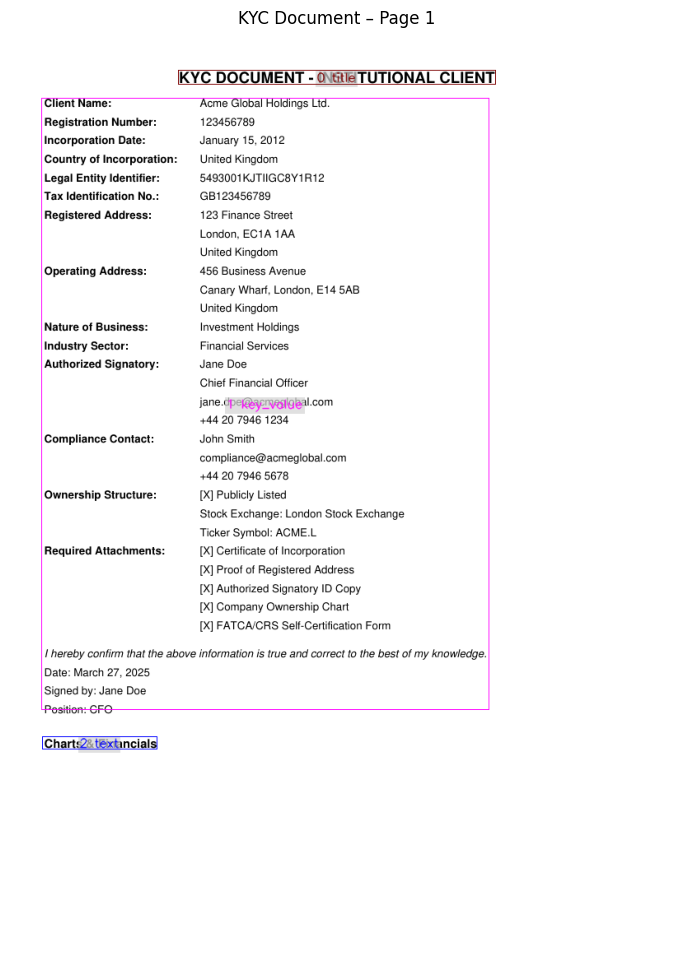

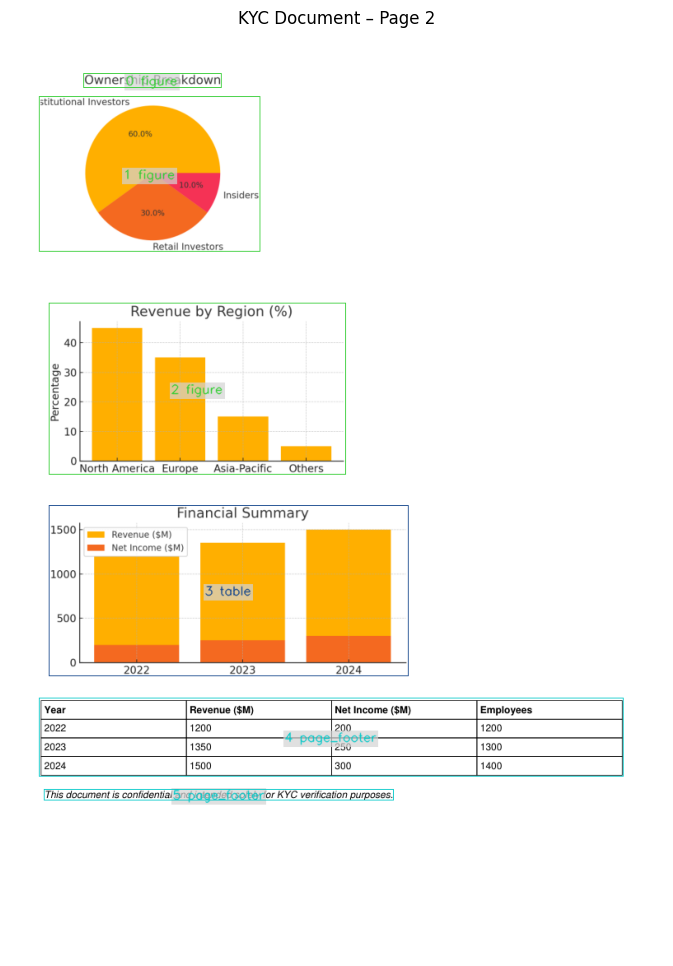

In [7]:
# Load visualizations (make sure the paths are correct)
page1_path = "./visualizations/KYC_EXAMPLE_DOC_viz_page_0.png"
page2_path = "./visualizations/KYC_EXAMPLE_DOC_viz_page_1.png"

# Open images
visual_grounding_image_page1 = Image.open(page1_path)
visual_grounding_image_page2 = Image.open(page2_path)

# Define a display function
def show_image(image, title=None):
    plt.figure(figsize=(10, 12))
    if title:
        plt.title(title)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Display
show_image(visual_grounding_image_page1, "KYC Document – Page 1")
show_image(visual_grounding_image_page2, "KYC Document – Page 2")

### Markdown Visualization

In [8]:
display(Markdown(parsed_doc.markdown))

# KYC DOCUMENT - INSTITUTIONAL CLIENT <!-- title, from page 0 (l=0.258,t=0.042,r=0.741,b=0.056), with ID 82a32028-9641-4ac9-88ef-9f6420a117d1 -->

## Client Information

- **Client Name**: Acme Global Holdings Ltd.
- **Registration Number**: 123456789
- **Incorporation Date**: January 15, 2012
- **Country of Incorporation**: United Kingdom
- **Legal Entity Identifier**: 5493001KJTII8C8Y1R12
- **Tax Identification No.**: GB123456789
- **Registered Address**: 
  - 123 Finance Street
  - London, EC1A 1AA
  - United Kingdom

## Operating Address

- **Address**: 
  - 456 Business Avenue
  - Canary Wharf, London, E14 5AB
  - United Kingdom

## Business Details

- **Nature of Business**: Investment Holdings
- **Industry Sector**: Financial Services

## Authorized Signatory

- **Name**: Jane Doe
- **Position**: Chief Financial Officer
- **Email**: jane.doe@acmeglobal.com
- **Phone**: +44 20 7946 1234

## Compliance Contact

- **Name**: John Smith
- **Email**: compliance@acmeglobal.com
- **Phone**: +44 20 7946 5678

## Ownership Structure

- **Publicly Listed**: [x]
- **Stock Exchange**: London Stock Exchange
- **Ticker Symbol**: ACME.L

## Required Attachments

- [x] Certificate of Incorporation
- [x] Proof of Registered Address
- [x] Authorized Signatory ID Copy
- [x] Company Ownership Chart
- [x] FATCA/CRS Self-Certification Form

---

I hereby confirm that the above information is true and correct to the best of my knowledge.

- **Date**: March 27, 2025
- **Signed by**: Jane Doe
- **Position**: CFO <!-- key_value, from page 0 (l=0.049,t=0.072,r=0.731,b=0.733), with ID 0566cb52-c802-4058-8db4-cdc6054e1ff1 -->

## Charts & Financials <!-- text, from page 0 (l=0.050,t=0.763,r=0.224,b=0.775), with ID 8c003f44-c597-4ae4-974c-a412baad434c -->

## Ownership Breakdown

The image is a cropped section of a document with the text "Ownership Breakdown." This appears to be a heading or title, indicating that the following content would likely detail the distribution or allocation of ownership, possibly in a business or financial context. There are no additional visual elements, checkboxes, or data points visible in this crop. <!-- figure, from page 1 (l=0.113,t=0.045,r=0.321,b=0.059), with ID 536e4938-46db-4a7f-b708-d7711da0e65a -->

## Pie Chart Description

This pie chart illustrates the distribution of investors in a company, divided into three categories:

- **Institutional Investors**: Represent the largest segment, occupying 60% of the chart. This section is colored in a bright orange shade.
- **Retail Investors**: Make up 30% of the total, depicted in a darker orange color.
- **Insiders**: Comprise the smallest portion at 10%, shown in a red color.

Each segment is clearly labeled with its respective percentage. The chart does not include a title or additional annotations. The labels for "Institutional Investors" and "Retail Investors" are slightly cut off, but their meaning is clear from context. <!-- figure, from page 1 (l=0.045,t=0.070,r=0.381,b=0.237), with ID 96145ae3-dd63-445d-be76-768c813937f7 -->

## Revenue by Region (%)

This bar chart illustrates the percentage of revenue generated by different regions. The chart is titled "Revenue by Region (%)" and uses a vertical bar format with the following details:

- **X-Axis (Regions)**:
  - North America
  - Europe
  - Asia-Pacific
  - Others

- **Y-Axis (Percentage)**:
  - The scale ranges from 0% to 50%, marked at intervals of 10%.

### Data Points:

- **North America**: Approximately 42%
- **Europe**: Approximately 35%
- **Asia-Pacific**: Approximately 15%
- **Others**: Approximately 8%

### Observations:

- North America has the highest revenue percentage, followed by Europe.
- Asia-Pacific and Others contribute significantly less, with Others being the lowest.
- The bars are colored in orange, providing a clear visual distinction between the regions. <!-- figure, from page 1 (l=0.060,t=0.293,r=0.513,b=0.478), with ID 81ab6b83-e8ca-4e57-b5f3-9813387332ab -->

## Financial Summary

The image is a bar chart titled "Financial Summary," displaying financial data for the years 2022, 2023, and 2024. The chart includes two categories: Revenue and Net Income, both measured in millions of dollars (M$).

### Legend
- **Revenue ($M)**: Represented by a large orange section in each bar.
- **Net Income ($M)**: Represented by a smaller red section at the bottom of each bar.

### Data Points
- **2022**:
  - Total Revenue: Approximately $1,500 million.
  - Net Income: Approximately $200 million.
  
- **2023**:
  - Total Revenue: Approximately $1,500 million.
  - Net Income: Approximately $200 million.
  
- **2024**:
  - Total Revenue: Approximately $1,500 million.
  - Net Income: Approximately $200 million.

### Observations
- The total revenue remains consistent across all three years at around $1,500 million.
- The net income also remains consistent at approximately $200 million each year.
- The chart indicates stability in both revenue and net income over the three-year period. <!-- table, from page 1 (l=0.060,t=0.513,r=0.608,b=0.696), with ID 4e736fd9-2ac9-43ba-a341-d72e32c3daca -->

### Table of Financial Data

This table presents financial data for the years 2022, 2023, and 2024. It includes columns for Revenue, Net Income, and the number of Employees.

<table>
  <tr>
    <th>Year</th>
    <th>Revenue ($M)</th>
    <th>Net Income ($M)</th>
    <th>Employees</th>
  </tr>
  <tr>
    <td>2022</td>
    <td>1200</td>
    <td>200</td>
    <td>1200</td>
  </tr>
  <tr>
    <td>2023</td>
    <td>1350</td>
    <td>250</td>
    <td>1300</td>
  </tr>
  <tr>
    <td>2024</td>
    <td>1500</td>
    <td>300</td>
    <td>1400</td>
  </tr>
</table>

- **Revenue**: Shows a steady increase from $1200M in 2022 to $1500M in 2024.
- **Net Income**: Increases from $200M in 2022 to $300M in 2024.
- **Employees**: The number of employees grows from 1200 in 2022 to 1400 in 2024. <!-- page_footer, from page 1 (l=0.045,t=0.721,r=0.936,b=0.804), with ID 2280af02-78b8-48b9-aa8e-7e90b1b7d622 -->

### Page Footer

This document is confidential and intended solely for KYC verification purposes. <!-- page_footer, from page 1 (l=0.053,t=0.819,r=0.585,b=0.831), with ID b9831cd5-db46-475a-a9c9-6f4a80cb7e20 -->

### Chunks

In [9]:
print(parsed_doc.chunks)  # Get the extracted data as structured chunks of content

[Chunk(text='# KYC DOCUMENT - INSTITUTIONAL CLIENT', grounding=[ChunkGrounding(page=0, box=ChunkGroundingBox(l=0.2575, t=0.041538290293855744, r=0.74125, b=0.055678984861976845), image_path=PosixPath('groundings/KYC_EXAMPLE_DOC_20250411_155811/page_0/82a32028-9641-4ac9-88ef-9f6420a117d1_0.png'))], chunk_type=<ChunkType.title: 'title'>, chunk_id='82a32028-9641-4ac9-88ef-9f6420a117d1'), Chunk(text='## Client Information\n\n- **Client Name**: Acme Global Holdings Ltd.\n- **Registration Number**: 123456789\n- **Incorporation Date**: January 15, 2012\n- **Country of Incorporation**: United Kingdom\n- **Legal Entity Identifier**: 5493001KJTII8C8Y1R12\n- **Tax Identification No.**: GB123456789\n- **Registered Address**: \n  - 123 Finance Street\n  - London, EC1A 1AA\n  - United Kingdom\n\n## Operating Address\n\n- **Address**: \n  - 456 Business Avenue\n  - Canary Wharf, London, E14 5AB\n  - United Kingdom\n\n## Business Details\n\n- **Nature of Business**: Investment Holdings\n- **Industry S

## Field Extraction using OpenAI

### Example of Extracting the Compliance Contact and Their Email Address 

In [10]:
markdown_text = parsed_doc.markdown

prompt = f"""
Here is some structured markdown content:

{markdown_text}

Please extract the compliance contact and their email in the following JSON format:
{{"name": "", "email": ""}} 
"""

response = client.chat.completions.create(
    model="gpt-4o",  # aka "o3-mini"
    messages=[
        {"role": "user", "content": prompt}
    ],
    temperature=0.0
)

# Expected answers: "John Smith" & "compliance@acmeglobal.com"
print(response.choices[0].message.content)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
```json
{
  "name": "John Smith",
  "email": "compliance@acmeglobal.com"
}
```


### Example of Requirement Verification: Validating Missing Required Forms 

In [11]:
markdown_text = parsed_doc.markdown

prompt = f"""
Here is some structured markdown content:

{markdown_text}

Are there any missing required attachments? Please answer yes or no:
"""

response = client.chat.completions.create(
    model="gpt-4o",  # aka "o3-mini"
    messages=[
        {"role": "user", "content": prompt}
    ],
    temperature=0.0
)

# Expected answers: "No missing forms"
print(response.choices[0].message.content)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
No, there are no missing required attachments. All the required attachments are checked as present:

- Certificate of Incorporation
- Proof of Registered Address
- Authorized Signatory ID Copy
- Company Ownership Chart
- FATCA/CRS Self-Certification Form


---

# 4. Evaluation Pipeline using LangChain and OpenAI

## Convert the LandingAI Chunks to LangChain Documents

In [12]:
def chunks_to_documents(chunks):
    docs = []
    for chunk in chunks:
        metadata = {
            "chunk_id": chunk.chunk_id,
            "chunk_type": chunk.chunk_type.value,
            "page": chunk.grounding[0].page if chunk.grounding else None
        }
        docs.append(Document(page_content=chunk.text, metadata=metadata))
    return docs

documents = chunks_to_documents(parsed_doc.chunks)

In [13]:
print(documents)

[Document(metadata={'chunk_id': '82a32028-9641-4ac9-88ef-9f6420a117d1', 'chunk_type': 'title', 'page': 0}, page_content='# KYC DOCUMENT - INSTITUTIONAL CLIENT'), Document(metadata={'chunk_id': '0566cb52-c802-4058-8db4-cdc6054e1ff1', 'chunk_type': 'key_value', 'page': 0}, page_content='## Client Information\n\n- **Client Name**: Acme Global Holdings Ltd.\n- **Registration Number**: 123456789\n- **Incorporation Date**: January 15, 2012\n- **Country of Incorporation**: United Kingdom\n- **Legal Entity Identifier**: 5493001KJTII8C8Y1R12\n- **Tax Identification No.**: GB123456789\n- **Registered Address**: \n  - 123 Finance Street\n  - London, EC1A 1AA\n  - United Kingdom\n\n## Operating Address\n\n- **Address**: \n  - 456 Business Avenue\n  - Canary Wharf, London, E14 5AB\n  - United Kingdom\n\n## Business Details\n\n- **Nature of Business**: Investment Holdings\n- **Industry Sector**: Financial Services\n\n## Authorized Signatory\n\n- **Name**: Jane Doe\n- **Position**: Chief Financial Of

## Instantiate the OpenAI Embeddings Model, Store the Embeddings in a Vectorstore and Create a Retriever

In [14]:
# OpenAI's Embedding Model
embedding_model = OpenAIEmbeddings(api_key=OPENAI_API_KEY)

# Vectorstore using FAISS
vectorstore = FAISS.from_documents(documents, embedding_model)

# Vectorstore Retriever
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
Loading faiss. (loader.py:148)
Successfully loaded faiss. (loader.py:150)
Failed to load GPU Faiss: name 'GpuIndexIVFFlat' is not defined. Will not load constructor refs for GPU indexes. (__init__.py:173)


## Create a QA Chain and Instantiate an OpenAI Model for Evaluation

In [15]:
# OpenAI LLM
llm = ChatOpenAI(api_key=OPENAI_API_KEY, model="gpt-4o", temperature=0)

# QA Chain
qa_chain = RetrievalQA.from_chain_type(llm=llm, retriever=retriever, return_source_documents=True)

## Create an Evaluation Dataset

### You can also use LLMs to generate your evaluation questions and answers!

In [16]:
eval_questions = [
    {
        "query": "What is the client's name?",
        "answer": "Acme Global Holdings Ltd."
    },
    {
        "query": "Are there any missing required attachments? Please answer yes or no.",
        "answer": "No"
    },
    {
        "query": "What is the breakdown of the ownership and which investors \
        have the highest ownership percentage?",
        "answer": "Institutional investors own 60%, insiders own 10%, and \
        retail investors own 30%. Institutional investors have the highest \
        percent ownership."
    },
    {
        "query": "What is the email address for compliance contact?",
        "answer": "compliance@acmeglobal.com"
    },
    {
        "query": "What region has the lowest revenue?",
        "answer": "Others"
    },
    {
        "query": "What is the YoY growth % for revenue?",
        "answer": "12.5% from 2022 to 2023 and 11.11% from 2023 to 2024."
    }
]

## Run Predictions 

In [17]:
predictions = []
for q in eval_questions:
    result = qa_chain.invoke({"query": q["query"]})
    predictions.append({
        "question": q["query"],
        "predicted_answer": result["result"],
        "ground_truth": q["answer"]
    })

HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embed

## Evaluate the Answers Using FAISS (Facebook AI Similarity Search)

In [18]:
eval_chain = QAEvalChain.from_llm(llm)
graded_outputs = eval_chain.evaluate(
    examples=[{"query": p["question"], "answer": p["ground_truth"]} for p in predictions],
    predictions=[{"query": p["question"], "result": p["predicted_answer"]} for p in predictions]
)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)


## Show the Results

In [19]:
for i, (pred, grade) in enumerate(zip(predictions, graded_outputs)):
    print(f"\nQ{i+1}: {pred['question']}")
    print(f"Prediction: {pred['predicted_answer']}")
    print(f"Ground Truth: {pred['ground_truth']}")

    score = grade.get("results", "No score")
    # print result
    print(f"Grade: {score}")



Q1: What is the client's name?
Prediction: The client's name is Acme Global Holdings Ltd.
Ground Truth: Acme Global Holdings Ltd.
Grade: CORRECT

Q2: Are there any missing required attachments? Please answer yes or no.
Prediction: I don't know.
Ground Truth: No
Grade: INCORRECT

Q3: What is the breakdown of the ownership and which investors         have the highest ownership percentage?
Prediction: The ownership breakdown is as follows:

- **Institutional Investors**: 60%
- **Retail Investors**: 30%
- **Insiders**: 10%

Institutional Investors have the highest ownership percentage at 60%.
Ground Truth: Institutional investors own 60%, insiders own 10%, and         retail investors own 30%. Institutional investors have the highest         percent ownership.
Grade: CORRECT

Q4: What is the email address for compliance contact?
Prediction: The email address for the compliance contact is compliance@acmeglobal.com.
Ground Truth: compliance@acmeglobal.com
Grade: CORRECT

Q5: What region has

## Repeat with AI-Generated Questions - Using LLMs for Evaluation

In [22]:
# Fill in the number of evaluation questions you want to test
num_questions = 10

prompt = f"""
Extract {num_questions} factual question-answer pairs from the following KYC document. Return them as a Python list of dictionaries in this format:

eval_questions_updated = [
    {{
        "query": "What is the client's name?",
        "answer": "Acme Global Holdings Ltd."
    }},
    ...
]

Here is the document:
\"\"\"
{markdown_text}
\"\"\"
"""

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": "You are a helpful assistant that extracts structured Q&A pairs from KYC documents."},
        {"role": "user", "content": prompt}
    ],
    temperature=0
)

raw_text = response.choices[0].message.content

# Find the Python list inside a code block
code_block_match = re.search(r"eval_questions_updated\s*=\s*(\[[\s\S]+\])", raw_text)

if code_block_match:
    eval_questions_llm = eval(code_block_match.group(1))
else:
    print("Could not parse eval_questions from response:")
    print(raw_text)
    eval_questions_llm = []

pprint(eval_questions_llm)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
[{'answer': 'Acme Global Holdings Ltd.', 'query': "What is the client's name?"},
 {'answer': '123456789',
  'query': 'What is the registration number of the client?'},
 {'answer': 'January 15, 2012', 'query': 'When was the client incorporated?'},
 {'answer': 'United Kingdom',
  'query': 'In which country is the client incorporated?'},
 {'answer': '5493001KJTII8C8Y1R12',
  'query': 'What is the legal entity identifier of the client?'},
 {'answer': '123 Finance Street, London, EC1A 1AA, United Kingdom',
  'query': 'What is the registered address of the client?'},
 {'answer': 'Jane Doe',
  'query': 'Who is the authorized signatory for the client?'},
 {'answer': 'compliance@acmeglobal.com',
  'query': 'What is the email address of the compliance contact?'},
 {'answer': 'Yes', 'query': 'Is the client publicly listed?'},
 {'answer': 'London Stock Exchange',
  'query': 'On which stock exchange is

In [23]:
predictions_llm = []
for q in eval_questions_llm:
    result = qa_chain.invoke({"query": q["query"]})
    predictions_llm.append({
        "question": q["query"],
        "predicted_answer": result["result"],
        "ground_truth": q["answer"]
    })

HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/embed

In [24]:
print(predictions_llm)

[{'question': "What is the client's name?", 'predicted_answer': "The client's name is Acme Global Holdings Ltd.", 'ground_truth': 'Acme Global Holdings Ltd.'}, {'question': 'What is the registration number of the client?', 'predicted_answer': 'The registration number of the client, Acme Global Holdings Ltd., is 123456789.', 'ground_truth': '123456789'}, {'question': 'When was the client incorporated?', 'predicted_answer': 'The client, Acme Global Holdings Ltd., was incorporated on January 15, 2012.', 'ground_truth': 'January 15, 2012'}, {'question': 'In which country is the client incorporated?', 'predicted_answer': 'The client, Acme Global Holdings Ltd., is incorporated in the United Kingdom.', 'ground_truth': 'United Kingdom'}, {'question': 'What is the legal entity identifier of the client?', 'predicted_answer': 'The legal entity identifier of the client, Acme Global Holdings Ltd., is 5493001KJTII8C8Y1R12.', 'ground_truth': '5493001KJTII8C8Y1R12'}, {'question': 'What is the register

In [25]:
eval_chain_llm = QAEvalChain.from_llm(llm)
graded_outputs_llm = eval_chain_llm.evaluate(
    examples=[{"query": p["question"], "answer": p["ground_truth"]} for p in predictions],
    predictions=[{"query": p["question"], "result": p["predicted_answer"]} for p in predictions]
)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK" (_client.py:1025)


In [26]:
for i, (pred, grade) in enumerate(zip(predictions_llm, graded_outputs_llm)):
    print(f"\nQ{i+1}: {pred['question']}")
    print(f"Prediction: {pred['predicted_answer']}")
    print(f"Ground Truth: {pred['ground_truth']}")

    score = grade.get("results", "No score")
    # print result
    print(f"Grade: {score}")



Q1: What is the client's name?
Prediction: The client's name is Acme Global Holdings Ltd.
Ground Truth: Acme Global Holdings Ltd.
Grade: CORRECT

Q2: What is the registration number of the client?
Prediction: The registration number of the client, Acme Global Holdings Ltd., is 123456789.
Ground Truth: 123456789
Grade: INCORRECT

Q3: When was the client incorporated?
Prediction: The client, Acme Global Holdings Ltd., was incorporated on January 15, 2012.
Ground Truth: January 15, 2012
Grade: CORRECT

Q4: In which country is the client incorporated?
Prediction: The client, Acme Global Holdings Ltd., is incorporated in the United Kingdom.
Ground Truth: United Kingdom
Grade: CORRECT

Q5: What is the legal entity identifier of the client?
Prediction: The legal entity identifier of the client, Acme Global Holdings Ltd., is 5493001KJTII8C8Y1R12.
Ground Truth: 5493001KJTII8C8Y1R12
Grade: CORRECT

Q6: What is the registered address of the client?
Prediction: The registered address of the clien